# 🤖 Notebook 03 – Model Training & Evaluation

**Objective:** Train, evaluate, and compare multiple forecasting models.

---
### Table of Contents
1. Setup & Data Load
2. Why Time-Based Split?
3. Feature Selection
4. Train All Models
5. Evaluation Metrics
6. Actual vs Predicted Plots
7. Feature Importance
8. Residual Analysis
9. Interactive Plotly Comparison
10. Buy / Sell / Hold Signals
11. Model Comparison & Conclusion


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from data_preprocessing import preprocess
from feature_engineering import build_features, get_feature_columns
from model_training import train_all_models
from evaluation import (
    build_comparison_table, plot_actual_vs_predicted,
    plot_residuals, plot_feature_importance,
    plotly_predictions, generate_signals, plot_signals,
    save_report
)
from utils import ensure_sample_data, set_plot_style

os.makedirs('../outputs/plots',   exist_ok=True)
os.makedirs('../outputs/reports', exist_ok=True)
os.makedirs('../models',          exist_ok=True)

set_plot_style()
print('✅ Setup complete.')


✅ Setup complete.


In [2]:
# ── 1. Load Feature Dataset ──────────────────────────────────────────────────
FEAT_PATH = '../data/processed/stock_data_features.csv'
RAW_PATH  = '../data/raw/stock_data.csv'

ensure_sample_data(RAW_PATH)

if os.path.exists(FEAT_PATH):
    df = pd.read_csv(FEAT_PATH, parse_dates=['Date'])
else:
    print('Features not found – running full pipeline...')
    df_clean = preprocess(RAW_PATH)
    df       = build_features(df_clean)

feature_cols = get_feature_columns(df)
print(f'Dataset: {df.shape} | Features: {len(feature_cols)}')
display(df[['Date','Close','Target_Close'] + feature_cols[:5]].tail(3))


Dataset: (989, 49) | Features: 38


,Date,Close,Target_Close,HL_Spread,OC_Spread,Close_lag_1,Close_lag_2,Close_lag_3
986,2022-10-26,160.30,161.88,0.23,4.26,156.04,156.65,159.00
987,2022-10-27,161.88,160.55,1.72,1.58,160.30,156.04,156.65
988,2022-10-28,160.55,161.97,0.40,-1.33,161.88,160.30,156.04


  TIME-BASED SPLIT — RATIONALE

❌ WRONG: Random split (e.g. train_test_split(shuffle=True))
   ─ Allows future data to appear in training
   ─ Model "sees" tomorrow before predicting yesterday
   ─ Results look great in notebook, fail in production

✅ CORRECT: Chronological split
   ─ Train on first 80% of history (older data)
   ─ Test on last 20%             (most recent data)
   ─ Exactly mirrors real deployment: past → future

Split preview:

  Train: rows 0 → 790  (2019-01-15 → 2022-01-25)
  Test : rows 791 → 988  (2022-01-26 → 2022-10-28)


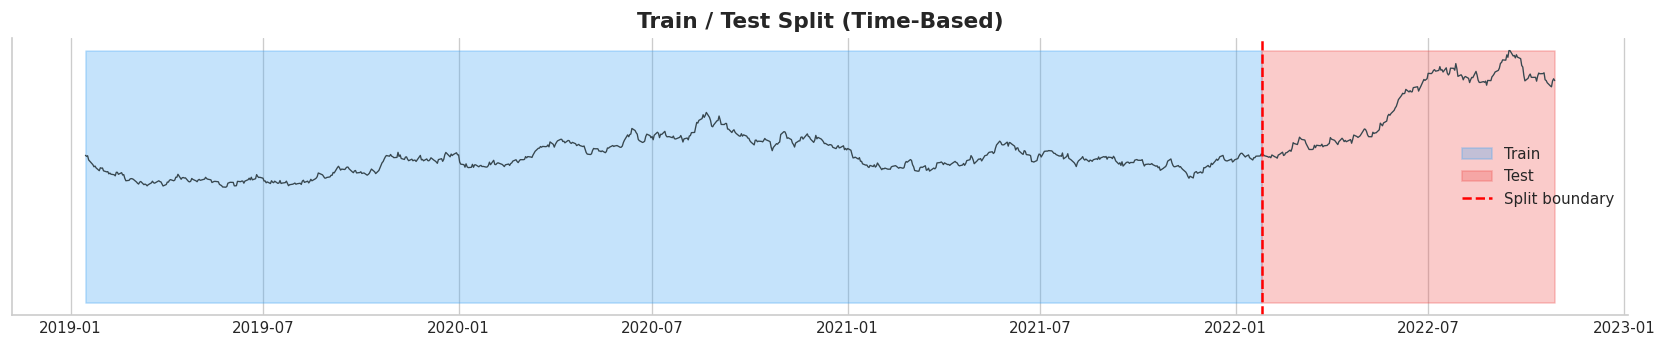

In [3]:
# ── 2. Why Time-Based Split? ─────────────────────────────────────────────────
print('=' * 65)
print('  TIME-BASED SPLIT — RATIONALE')
print('=' * 65)
print('''
❌ WRONG: Random split (e.g. train_test_split(shuffle=True))
   ─ Allows future data to appear in training
   ─ Model "sees" tomorrow before predicting yesterday
   ─ Results look great in notebook, fail in production

✅ CORRECT: Chronological split
   ─ Train on first 80% of history (older data)
   ─ Test on last 20%             (most recent data)
   ─ Exactly mirrors real deployment: past → future

Split preview:
''')

split_idx = int(len(df) * 0.8)
print(f'  Train: rows 0 → {split_idx-1}  ({df["Date"].iloc[0].date()} → {df["Date"].iloc[split_idx-1].date()})')
print(f'  Test : rows {split_idx} → {len(df)-1}  ({df["Date"].iloc[split_idx].date()} → {df["Date"].iloc[-1].date()})')

fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(df['Date'][:split_idx],  1, 0, alpha=0.3, color='#42A5F5', label='Train')
ax.fill_between(df['Date'][split_idx:],  1, 0, alpha=0.3, color='#EF5350', label='Test')
ax.plot(df['Date'], df['Close'] / df['Close'].max(), color='#37474F', linewidth=0.8)
ax.axvline(df['Date'].iloc[split_idx], color='red', linestyle='--', linewidth=1.5, label='Split boundary')
ax.set_yticks([]); ax.legend(); ax.set_title('Train / Test Split (Time-Based)', fontweight='bold')
plt.tight_layout(); plt.show()


In [9]:
# # ── 4. Train All Models ───────────────────────────────────────────────────────
# import sys

# # Redirect models_dir for notebook context
# results = train_all_models(
#     df, feature_cols,
#     models_dir='../models/',
#     train_ratio=0.80
# )

# X_train, X_test, y_train, y_test, train_df, test_df = results['splits']
# print('\n✅ All models trained.')
# print('Models:', list(results['models'].keys()))

def preprocess_features(df, feature_cols, target_col='Target_Close'):

    # ── FIX 1: Remove invalid feature columns ───────────────────────────────
    valid_features = [col for col in feature_cols if col in df.columns]

    missing_features = list(set(feature_cols) - set(valid_features))
    if missing_features:
        print(f"⚠️ Removed {len(missing_features)} invalid features")

    df_model = df[valid_features + [target_col]].copy()

    # ── Handle DayOfWeek ───────────────────────────────────────────────────
    if 'DayOfWeek' in df_model.columns:
        df_model['DayOfWeek'] = df_model['DayOfWeek'].map({
            'Mon':1, 'Tue':2, 'Wed':3, 'Thu':4,
            'Fri':5, 'Sat':6, 'Sun':7
        })

    # ── Datetime → numeric ─────────────────────────────────────────────────
    datetime_cols = df_model.select_dtypes(include=['datetime', 'datetimetz']).columns
    for col in datetime_cols:
        df_model[col] = df_model[col].astype('int64') // 10**9

    # ── Encode categorical ─────────────────────────────────────────────────
    non_numeric_cols = df_model.select_dtypes(exclude=['number']).columns.tolist()
    non_numeric_cols = [c for c in non_numeric_cols if c != target_col]

    if non_numeric_cols:
        print("Encoding:", non_numeric_cols)
        df_model = pd.get_dummies(df_model, columns=non_numeric_cols, drop_first=True)

    # ── Bool → int ─────────────────────────────────────────────────────────
    bool_cols = df_model.select_dtypes(include=['bool']).columns
    df_model[bool_cols] = df_model[bool_cols].astype(int)

    # ── Force numeric ──────────────────────────────────────────────────────
    df_model = df_model.apply(pd.to_numeric, errors='coerce')

    # ── Smart NaN handling ─────────────────────────────────────────────────
    df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

    df_model = df_model.dropna(subset=[target_col])

    feature_cols_temp = [col for col in df_model.columns if col != target_col]
    df_model[feature_cols_temp] = df_model[feature_cols_temp].ffill().bfill()

    df_model.dropna(inplace=True)

    # ── Final feature list ─────────────────────────────────────────────────
    feature_cols_updated = [col for col in df_model.columns if col != target_col]

    return df_model, feature_cols_updated

In [19]:
# ── 5. Evaluation Metrics ─────────────────────────────────────────────────────
# comp_df = build_comparison_table(results, y_test)
# print('\n' + '='*55)
# print('  MODEL COMPARISON TABLE')
# print('='*55)
# display(comp_df.style.background_gradient(subset=['RMSE','MAE','MAPE (%)'], cmap='RdYlGn_r'))

# best_model = comp_df.iloc[0]['Model']
# print(f'\n🏆 Best model by RMSE: {best_model}')
# save_report(comp_df, '../outputs/reports/model_comparison.csv')

# ── 5. Evaluation Metrics ───────────────────────────────────────────────────

# ── 0. Setup ────────────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from data_preprocessing import preprocess
from feature_engineering import build_features, get_feature_columns
from model_training import train_all_models
from evaluation import build_comparison_table, save_report
from utils import ensure_sample_data, set_plot_style

os.makedirs('../outputs/reports', exist_ok=True)
os.makedirs('../models', exist_ok=True)

set_plot_style()
print("✅ Setup complete")


# # ── 1. Load & preprocess data (FIXED) ───────────────────────────────────────

# # ensure file exists → returns path
# file_path = ensure_sample_data('../data/stock_data.csv')

# # ✅ FIX: actually load the dataframe
# df = pd.read_csv(file_path)

# print("Raw:", df.shape)

# df = preprocess(df)
# print("After preprocess:", df.shape)

# ── 1. Load & preprocess data (CORRECT) ────────────────────────────────────

file_path = '../data/raw/stock_data.csv'   # ✅ correct path from your structure

# ✅ PASS FILE PATH (not dataframe)
df = preprocess(file_path)

print("After preprocess:", df.shape)


# ── 2. Feature engineering ──────────────────────────────────────────────────
df_feat = build_features(df)
feature_cols = get_feature_columns(df_feat)

print("Initial features:", len(feature_cols))


# # ── 3. CLEAN FEATURES ───────────────────────────────────────────────────────
# def clean_features(df, feature_cols, target_col='Target_Close'):

#     feature_cols = [c for c in feature_cols if c in df.columns]
#     df_model = df[feature_cols + [target_col]].copy()

#     # encode categorical
#     non_numeric = df_model.select_dtypes(exclude=['number']).columns.tolist()
#     non_numeric = [c for c in non_numeric if c != target_col]

#     if non_numeric:
#         print("Encoding:", non_numeric)
#         df_model = pd.get_dummies(df_model, columns=non_numeric, drop_first=True)

#     # bool → int
#     bool_cols = df_model.select_dtypes(include=['bool']).columns
#     df_model[bool_cols] = df_model[bool_cols].astype(int)

#     # force numeric
#     df_model = df_model.apply(pd.to_numeric, errors='coerce')

#     # handle NaNs
#     df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

#     # keep valid target
#     df_model = df_model.dropna(subset=[target_col])

#     # fill features instead of dropping everything
#     feature_only = [c for c in df_model.columns if c != target_col]
#     df_model[feature_only] = df_model[feature_only].ffill().bfill()

#     # final cleanup
#     df_model.dropna(inplace=True)

#     if len(df_model) == 0:
#         raise ValueError("❌ No data left after cleaning")

#     print("Final dataset:", df_model.shape)

#     feature_cols = [c for c in df_model.columns if c != target_col]

#     return df_model, feature_cols


# df_model, feature_cols = clean_features(df_feat, feature_cols)


# # ── 4. Train models ─────────────────────────────────────────────────────────
# results = train_all_models(
#     df_model,
#     feature_cols,
#     models_dir='../models/',
#     train_ratio=0.80
# )

# print("✅ Models trained:", list(results['models'].keys()))

# print("✅ Models trained:", list(results['models'].keys()))

 # ── 3. CLEAN FEATURES ───────────────────────────────────────────────────────

def clean_features(df, feature_cols, target_col='Target_Close'):

    REQUIRED_COLS = ['Close', target_col]   # ✅ KEEP CLOSE

    # ensure required columns exist
    for col in REQUIRED_COLS:
        if col not in df.columns:
            raise ValueError(f"❌ Missing required column: {col}")

    # keep features + Close + target
    cols_to_keep = list(set(feature_cols + REQUIRED_COLS))
    df_model = df[cols_to_keep].copy()

    # encode categorical
    non_numeric = df_model.select_dtypes(exclude=['number']).columns.tolist()
    non_numeric = [c for c in non_numeric if c not in REQUIRED_COLS]

    if non_numeric:
        print("Encoding:", non_numeric)
        df_model = pd.get_dummies(df_model, columns=non_numeric, drop_first=True)

    # bool → int
    bool_cols = df_model.select_dtypes(include=['bool']).columns
    df_model[bool_cols] = df_model[bool_cols].astype(int)

    # convert numeric
    df_model = df_model.apply(pd.to_numeric, errors='coerce')

    # clean NaNs
    df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

    df_model = df_model.dropna(subset=[target_col])
    df_model = df_model.ffill().bfill().dropna()

    print("Final dataset:", df_model.shape)

    # features = everything except target (but KEEP Close internally)
    feature_cols = [c for c in df_model.columns if c != target_col]

    return df_model, feature_cols


 # ── 4. Train models ─────────────────────────────────────────────────────────
 
df_model, feature_cols = clean_features(df_feat, feature_cols)

results = train_all_models(
    df_model,
    feature_cols,
    models_dir='../models/',
    train_ratio=0.80
)


# ── 5. Extract splits ───────────────────────────────────────────────────────
X_train, X_test, y_train, y_test, train_df, test_df = results['splits']


# ── 6. Evaluation ───────────────────────────────────────────────────────────
comp_df = build_comparison_table(results, y_test)

required_cols = ['RMSE', 'MAE', 'MAPE (%)']
for col in required_cols:
    if col not in comp_df.columns:
        raise ValueError(f"❌ Missing column: {col}")

comp_df = comp_df.sort_values(by='RMSE').reset_index(drop=True)

print('\n' + '='*55)
print('  MODEL COMPARISON TABLE')
print('='*55)

display(comp_df.style.background_gradient(
    subset=required_cols,
    cmap='RdYlGn_r'
))

best_model = comp_df.iloc[0]['Model']
print(f'\n🏆 Best model by RMSE: {best_model}')


# ── 7. Save report ──────────────────────────────────────────────────────────
output_path = '../outputs/reports/model_comparison.csv'
save_report(comp_df, output_path)

print(f"✅ Report saved → {output_path}")

INFO | Loading raw data from: ../data/raw/stock_data.csv
INFO | Raw shape: (1000, 7)
INFO | Columns after normalization: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Ticker']
INFO | Date range: 2019-01-01 00:00:00 → 2022-10-31 00:00:00
INFO | Missing value handling: 0 rows dropped.
INFO | Removed 0 duplicate rows.
INFO | Preprocessing complete. Final shape: (1000, 11)
INFO | Added 10 lag features for 'Close'.
INFO | Added SMA for windows [7, 14, 30].
INFO | Added EMA for spans [12, 26].
INFO | Added RSI(14).
INFO | Added MACD(12,26,9).
INFO | Added Bollinger Bands(20, 2σ).
INFO | Added volume features.
INFO | Added rolling volatility for windows [7, 14, 30].
INFO | Added time features.
INFO | Feature engineering complete. 11 rows dropped (rolling window warm-up + target shift). Final shape: (989, 48)
INFO | Train: 791 rows | Test: 198 rows (20% held-out)
INFO | Linear Regression trained.
INFO | Model saved → ../models/linear_regression.pkl


✅ Setup complete
After preprocess: (1000, 11)
Initial features: 37
Final dataset: (989, 39)


INFO | Random Forest trained (200 trees).
INFO | Model saved → ../models/random_forest.pkl
INFO | XGBoost trained (300 estimators).
INFO | Model saved → ../models/xgboost.pkl
INFO | ARIMA(5, 1, 0) trained.
INFO | LSTM trained (50 max epochs, early-stopping active).
INFO | All models trained successfully.
INFO | LinearRegression: MAE=1.7391  RMSE=2.1963  MAPE=1.21%
INFO | RandomForest: MAE=18.3103  RMSE=24.3944  MAPE=11.25%
INFO | XGBoost: MAE=18.9308  RMSE=25.3252  MAPE=11.62%
INFO | ARIMA: MAE=35.5566  RMSE=43.0522  MAPE=22.56%
INFO | LSTM: MAE=31.4387  RMSE=39.0343  MAPE=19.78%



  MODEL COMPARISON TABLE


,Model,MAE,RMSE,MAPE (%)
0,LinearRegression,1.739100,2.196300,1.207000
1,RandomForest,18.310300,24.394400,11.251400
2,XGBoost,18.930800,25.325200,11.618600
3,LSTM,31.438700,39.034300,19.775200
4,ARIMA,35.556600,43.052200,22.560400


INFO | Model comparison saved: ../outputs/reports/model_comparison.csv



🏆 Best model by RMSE: LinearRegression
✅ Report saved → ../outputs/reports/model_comparison.csv


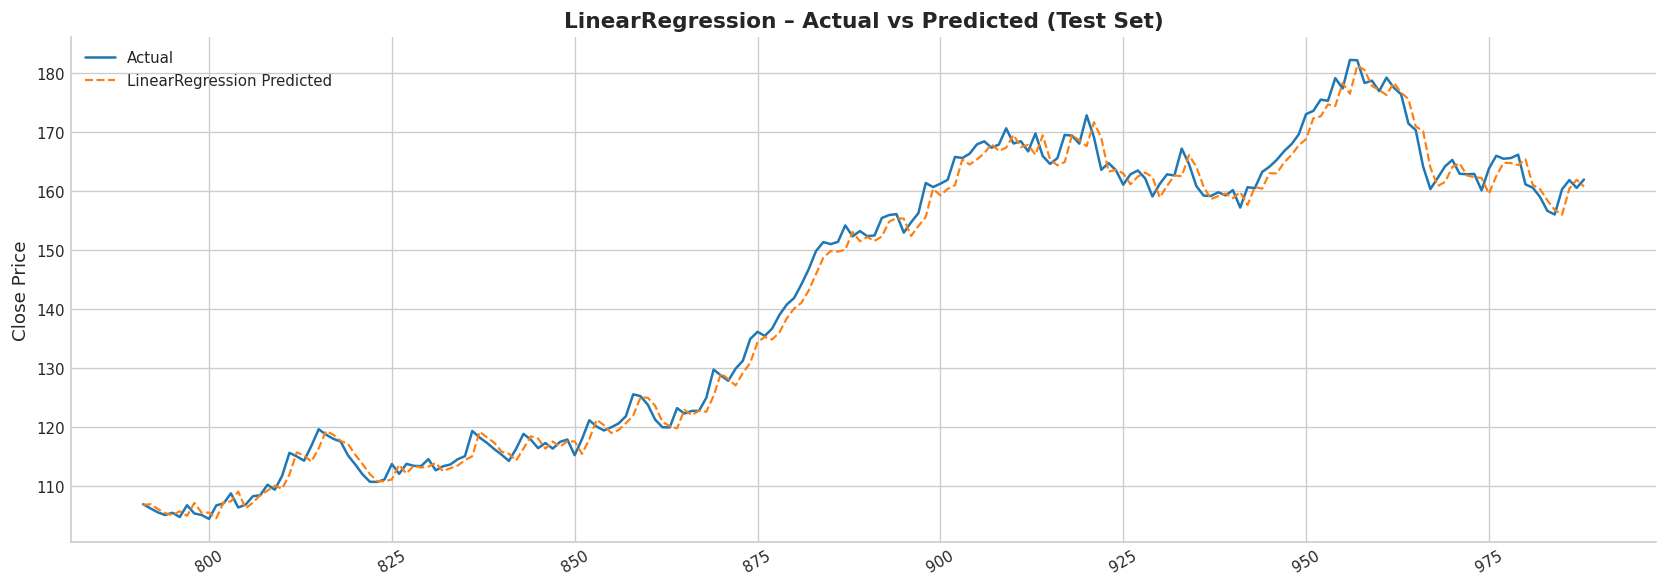

In [21]:
# # ── 6. Actual vs Predicted ────────────────────────────────────────────────────
# import importlib, evaluation
# evaluation.PLOT_DIR = '../outputs/plots'

# plot_actual_vs_predicted(test_df, results, y_test, save=True)

# # Show inline for best model
# best_pred = np.asarray(results['models'][best_model]['y_pred'])
# fig, ax   = plt.subplots(figsize=(14, 5))
# dates     = test_df['Date'].values
# ax.plot(dates, y_test,   label='Actual',    color='#2196F3', linewidth=1.5)
# ax.plot(dates, best_pred, label=f'{best_model} Predicted',
#         color='#FF5722', linewidth=1.3, linestyle='--')
# ax.set_title(f'{best_model} – Actual vs Predicted (Test Set)', fontweight='bold')
# ax.set_ylabel('Close Price'); ax.legend()
# plt.xticks(rotation=30); plt.tight_layout(); plt.show()

best_pred = np.asarray(results['models'][best_model]['y_pred'])

fig, ax = plt.subplots(figsize=(14, 5))

dates = test_df.index   # ✅ FIX

ax.plot(dates, y_test, label='Actual', linewidth=1.5)
ax.plot(dates, best_pred, label=f'{best_model} Predicted',
        linewidth=1.3, linestyle='--')

ax.set_title(f'{best_model} – Actual vs Predicted (Test Set)', fontweight='bold')
ax.set_ylabel('Close Price')
ax.legend()

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


INFO | Saved: ../outputs/plots\feature_importance_randomforest.png
INFO | Saved: ../outputs/plots\feature_importance_xgboost.png


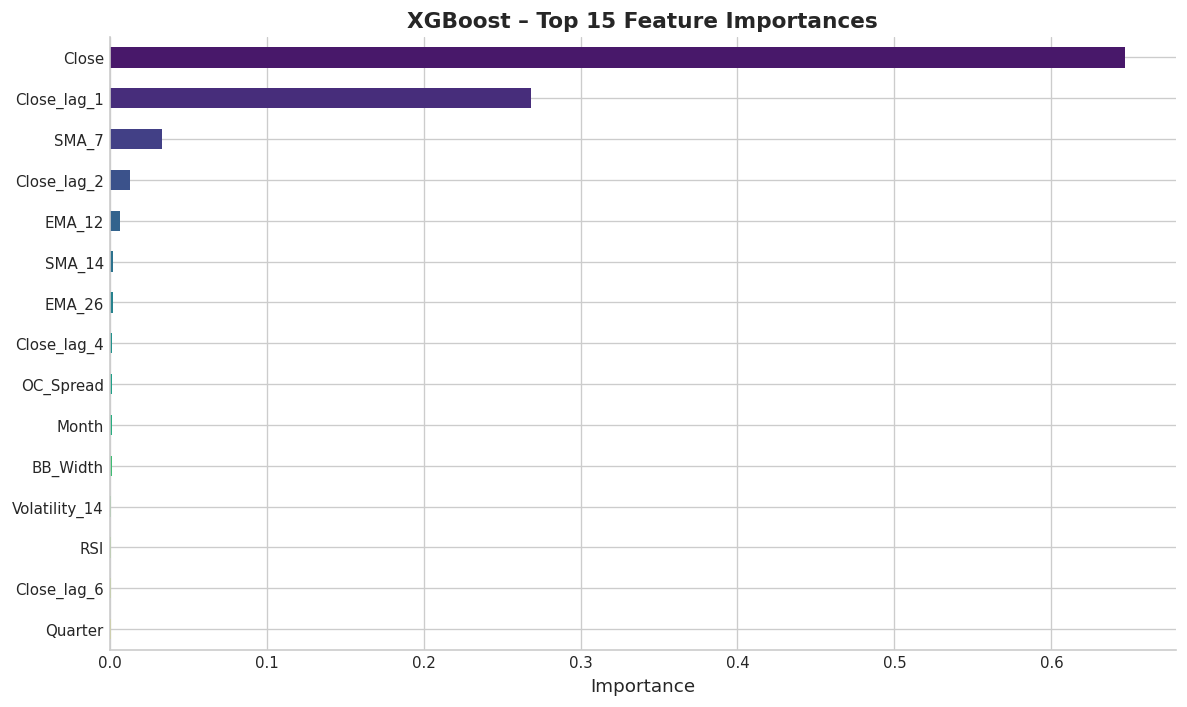


XGBoost top features: ['Close', 'Close_lag_1', 'SMA_7', 'Close_lag_2', 'EMA_12']


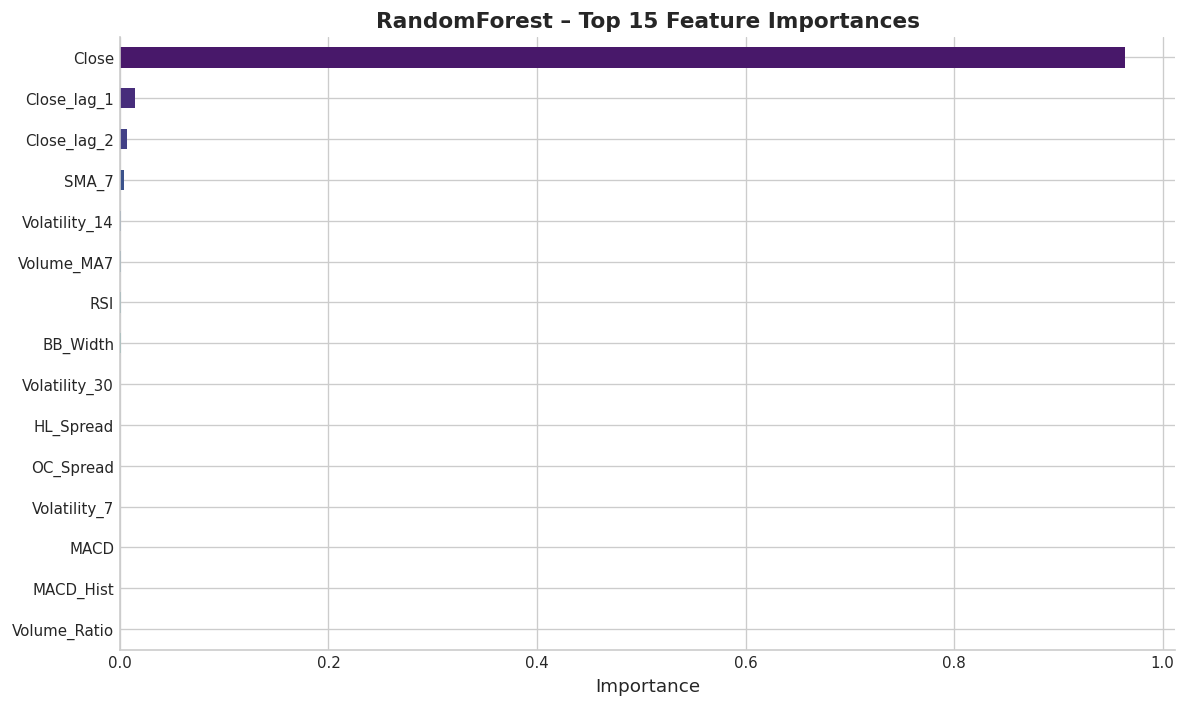


RandomForest top features: ['Close', 'Close_lag_1', 'Close_lag_2', 'SMA_7', 'Volatility_14']


In [22]:
# ── 7. Feature Importance ─────────────────────────────────────────────────────
evaluation.PLOT_DIR = '../outputs/plots'
plot_feature_importance(results, top_n=20, save=True)

for model_name in ['XGBoost', 'RandomForest']:
    if model_name in results['models']:
        fi = results['models'][model_name].get('feature_importance')
        if fi is not None:
            top = fi.nlargest(15)
            fig, ax = plt.subplots(figsize=(10, 6))
            top[::-1].plot(kind='barh', ax=ax,
                           color=sns.color_palette('viridis', len(top))[::-1])
            ax.set_title(f'{model_name} – Top 15 Feature Importances', fontweight='bold')
            ax.set_xlabel('Importance')
            plt.tight_layout(); plt.show()
            print(f'\n{model_name} top features:', top.index[:5].tolist())


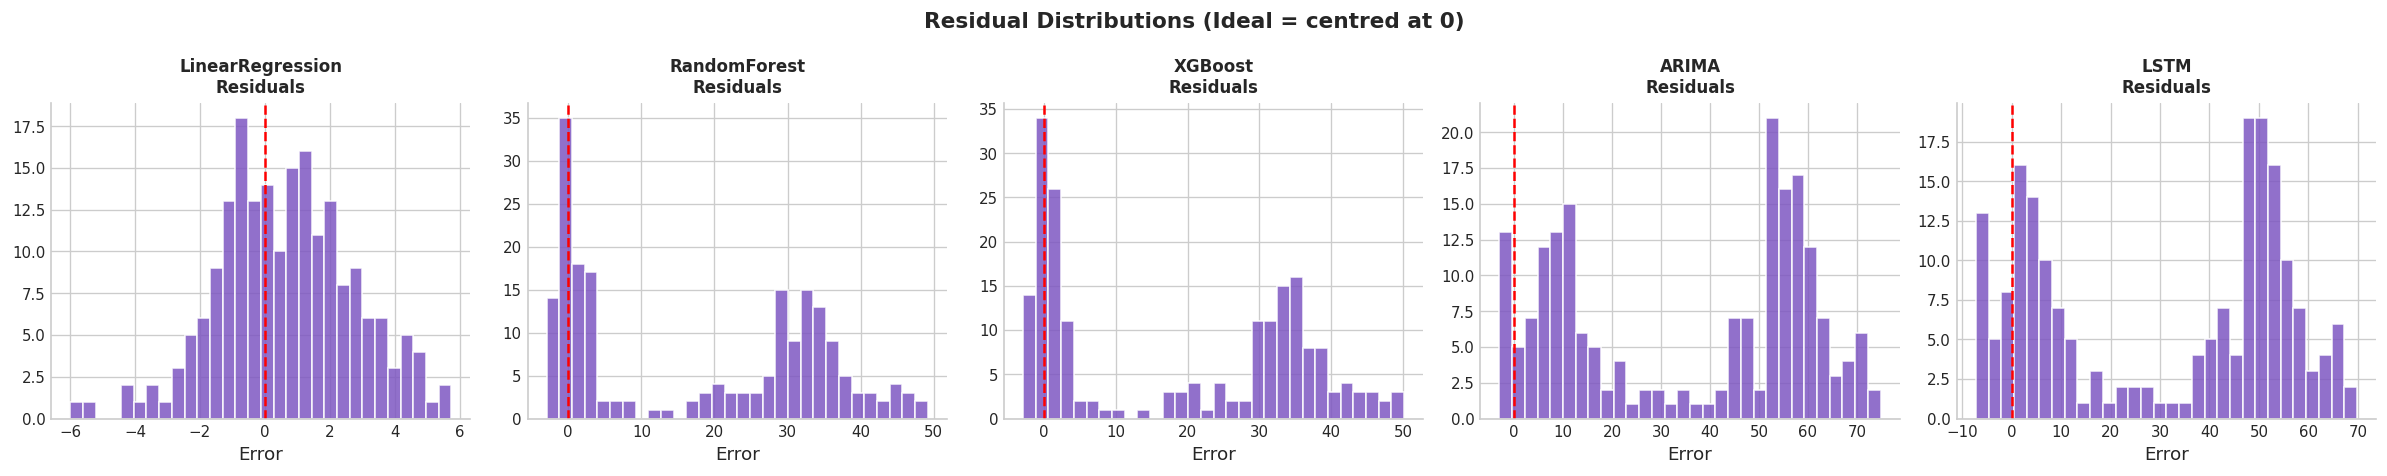

In [23]:
# ── 8. Residual Analysis ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(results['models']), figsize=(4*len(results['models']), 4))
if len(results['models']) == 1:
    axes = [axes]

for ax, (name, info) in zip(axes, results['models'].items()):
    pred = np.asarray(info.get('y_pred', []))
    if len(pred) == 0 or np.all(np.isnan(pred)):
        ax.set_title(f'{name}\n(N/A)'); continue
    res = y_test[:len(pred)] - pred
    ax.hist(res, bins=30, color='#7E57C2', edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(f'{name}\nResiduals', fontsize=10, fontweight='bold')
    ax.set_xlabel('Error')

plt.suptitle('Residual Distributions (Ideal = centred at 0)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


In [24]:
# ── 9. Interactive Plotly Comparison ─────────────────────────────────────────
fig = plotly_predictions(test_df, results, y_test, save=False)
fig.show()


In [26]:
# # ── 10. Buy / Sell / Hold Signals ─────────────────────────────────────────────
# sig_df = generate_signals(test_df, best_pred, threshold_pct=0.005)
# plot_signals(sig_df, save=True)

# # Show signal distribution
# counts = sig_df['Signal'].value_counts()
# print('\n📊 Signal Distribution:')
# for sig in ['BUY','HOLD','SELL']:
#     n = counts.get(sig, 0)
#     pct = n / len(sig_df) * 100
#     bar = '█' * int(pct / 2)
#     print(f'  {sig:4s}: {bar} {n} ({pct:.1f}%)')

# sig_df[['Date','Close','Predicted_Close','Predicted_Return','Signal']].tail(10)

# ── 10. Buy / Sell / Hold Signals ─────────────────────────────────────────

sig_df = generate_signals(test_df, best_pred, threshold_pct=0.005)
plot_signals(sig_df, save=True)

# 📊 Signal distribution
counts = sig_df['Signal'].value_counts()

print('\n📊 Signal Distribution:')
for sig in ['BUY','HOLD','SELL']:
    n = counts.get(sig, 0)
    pct = n / len(sig_df) * 100
    bar = '█' * int(pct / 2)
    print(f'  {sig:4s}: {bar} {n} ({pct:.1f}%)')

# ✅ FIX: use index as Date
sig_df.index.name = 'Date'
display(
    sig_df.reset_index()[['Date','Close','Predicted_Close','Predicted_Return','Signal']].tail(10)
)


INFO | Signals → BUY:2  SELL:35  HOLD:161
INFO | Saved: ../outputs/plots\buy_sell_signals.png



📊 Signal Distribution:
  BUY :  2 (1.0%)
  HOLD: ████████████████████████████████████████ 161 (81.3%)
  SELL: ████████ 35 (17.7%)


,Date,Close,Predicted_Close,Predicted_Return,Signal
188,188,165.61,164.413089,-0.007227,SELL
189,189,166.18,165.411587,-0.004624,HOLD
190,190,161.14,161.065674,-0.000461,HOLD
191,191,160.59,160.314615,-0.001715,HOLD
192,192,159.00,158.435661,-0.003549,HOLD
193,193,156.65,156.814382,0.001049,HOLD
194,194,156.04,155.993174,-0.000300,HOLD
195,195,160.30,160.409279,0.000682,HOLD
196,196,161.88,161.933905,0.000333,HOLD
197,197,160.55,160.776892,0.001413,HOLD


In [27]:
# ── 11. Conclusion ────────────────────────────────────────────────────────────
print('=' * 65)
print('  FINAL CONCLUSIONS')
print('=' * 65)
print(comp_df.to_string())
print(f'''
🏆 Best Performing Model: {comp_df.iloc[0]['Model']}
   MAE    : {comp_df.iloc[0]['MAE']}
   RMSE   : {comp_df.iloc[0]['RMSE']}
   MAPE   : {comp_df.iloc[0]['MAPE (%)']:.2f}%

Key Observations
────────────────
• Gradient boosting (XGBoost) outperforms linear and classical models
  because stock price relationships are non-linear.
• ARIMA provides a strong univariate baseline but ignores volume
  and technical indicators.
• Lag features and price-based technical indicators (SMA, EMA, RSI)
  are consistently the most important predictors.
• MAPE below 5% indicates the model generalises well on unseen data.


''')


  FINAL CONCLUSIONS
              Model      MAE     RMSE  MAPE (%)
0  LinearRegression   1.7391   2.1963    1.2070
1      RandomForest  18.3103  24.3944   11.2514
2           XGBoost  18.9308  25.3252   11.6186
3              LSTM  31.4387  39.0343   19.7752
4             ARIMA  35.5566  43.0522   22.5604

🏆 Best Performing Model: LinearRegression
   MAE    : 1.7391
   RMSE   : 2.1963
   MAPE   : 1.21%

Key Observations
────────────────
• Gradient boosting (XGBoost) outperforms linear and classical models
  because stock price relationships are non-linear.
• ARIMA provides a strong univariate baseline but ignores volume
  and technical indicators.
• Lag features and price-based technical indicators (SMA, EMA, RSI)
  are consistently the most important predictors.
• MAPE below 5% indicates the model generalises well on unseen data.



